# 5 Levels of Search - from Past to Future

> An overview of where search engines started, where they are now and where they are headed.
- badges: true
- comments: true

Unstructured data contains a lot of valuable knowledge. However, the problem with it is that it is hard to access. Since there's no structure, you can't just grab what you want and move on.

One of the most important forms of unstructured data is text. Search engines are tools built to find information from text.

A search engine that anyone's familiar with, is a web search engine such as Google. If you think about it, the fact that you can search the entire web for information is terrific. There are hundreds of terabytes of raw text on the internet, yet somehow, by picking the right combination of keywords, you can find exactly what you're looking for. That is, if you're able to choose them.

Web search engines have a significant advantage in relevancy. Namely, it can take advantage of user and website data. For the former, it has information on what people search, what they click on, how long until they search again, where they're from, what their interests are, etc. For the latter, it is possible to rank websites according to their linking structure, user engagement, loading speed and more.

All of this information can be cleverly used, to produce highly relevant search results, even while having a superficial understanding of the knowledge that's returned.

As an example, Google knows that I often use programming related queries. So do many other people that also like to click on [Stackoverflow](https://stackoverflow.com/) links. Say there is evidence that 90% of people that are similar to myself, click on a particular Stackoverflow link for a specific search term. It makes sense to rank this result high, even if there is no *understanding* of relevancy on a content level. Some keywords will match, and that's great, but that's far from the reason the result was given a high ranking.

Using user data is just one of the many ways a search engine can provide relevant results. Most companies and people don't have such luxuries.

There is no silver bullet for the problem. The only solution is building an exceptional search engine that is able to understand what we want to find.

In the following five levels of search, we'll build an intelligent search engine from scratch to gain a deeper understanding of the problem. In the end, we'll see how the problem can be quickly solved using open-source libraries and what marvels await us in the future of search.

## Levels of search

Search is an significant enough field to have various solutions and software offerings for many different domains. To cut through the noise, I will be focusing on the fundamentals of text-based search. Each level will show the code behind the implementation. You may comfortably skip over the code and still build an intuitive understanding about the topic.

### Level 1 - Keyword matching

Starting from the very basics, we can search using keywords. It's very easy to come up with an algorithm that does just that.

The idea is to split every document into words, count occurrences and save the processed version, thus "indexing" it.

Once we query for a document, we'll do the same processing on the query and count exact keyword matches, thus "scoring" documents.

In [1]:
#hide
import re
import collections
import pprint

In [2]:
# Our documents
doc_1 = "Funny videos about cats"
doc_2 = "Cats, cats, cats!"
doc_3 = "silly dog videos"

Natural language is messy, so even at level 1, we should do some cleaning. Let's write a simple function to get keywords from text.

In [3]:
def text_to_keywords(document):
    # Turn to lowercase
    text = document.lower()
    # Remove special characters
    text = re.sub(r"[^a-z0-9 ]", "", text)
    # Split to keywords on space
    kws = text.split(" ")
    return kws

In [4]:
def level1_index_documents(documents):
    index = []
    for document in documents:
        # Get list of keywords
        kws = text_to_keywords(document)
        # Count keywords
        counts = collections.Counter(kws)
        # Nice index representation
        indexed_document = {"doc": document, "counts": dict(counts)}
        # Add to our index
        index.append(indexed_document)
    
    return index

In [5]:
level1_index = level1_index_documents([doc_1, doc_2, doc_3])

In [6]:
#hide_input
level1_index

[{'doc': 'Funny videos about cats',
  'counts': {'funny': 1, 'videos': 1, 'about': 1, 'cats': 1}},
 {'doc': 'Cats, cats, cats!', 'counts': {'cats': 3}},
 {'doc': 'silly dog videos', 'counts': {'silly': 1, 'dog': 1, 'videos': 1}}]

What we accomplished is counting how many times a keyword occurs in a document. That's about all we need to start searching for our documents. The final piece is a ranking function.

In [7]:
def level1_rank(query, index):
    results = []
    # Split query to keywords
    kws = text_to_keywords(query)
    for document in index:
        score = 0.0
        for kw in kws:
            # Add the count of keywords as the score
            score += document["counts"].get(kw) or 0.0
        
        result = {"doc": document, "score": score}
        results.append(result)
    
    # Sort results
    results = sorted(results, key=lambda x: x["score"], reverse=True)
    return results

Ranking simply adds a score of `1` every time a query keyword matches with a document keyword.

In [8]:
def search(query, rank_func, index):
    results = rank_func(query, index)
    for result in results:
        print(f"{result['doc']['doc']} \t {result['score']:.4f}".expandtabs(30))

After implementing a nice wrapper, we can start searching. Let's try to search for `cats`.

In [9]:
search("cats", level1_rank, level1_index)

Cats, cats, cats!              3.0000
Funny videos about cats        1.0000
silly dog videos               0.0000


Great! The two documents that mention cats are ranked at the top, while `dog videos` gets a score of `0.0`.

Search solved? Unfortunately not, far from it. If you're paying attention, I'm sure you have noticed a big red flag. The first document has a score that's `3x` higher than the second result. All because it has "stuffed" the keyword `cats`.

This brings us back to the early days of search engines, where people could rank pages high just by "stuffing" their content with repeated keywords. One such strategy involved writing the excess keywords in white font on a white background so only the indexing robots could read it. Clearly, this is not a great solution.

Let's look at another example to see what else is wrong with this approach.

In [10]:
search("cat videos", level1_rank, level1_index)

Funny videos about cats        1.0000
silly dog videos               1.0000
Cats, cats, cats!              0.0000


As you may have expected, `silly dog videos` and `cat videos` get precisely the same score. This is because our simple indexing system can't understand that singular and plural forms of words are basically the same thing. The only keyword that matches is `videos`.

All in all, these two red flags make this approach uninteresting. However, we did learn about two essential search concepts: indexing and scoring.

__Indexing__ is the process of processing and saving documents to make them easily scorable/retrievable for search queries.

__Scoring__ is the process of giving documents a score based on the query and information in the index.

These are the two crucial pieces that make every search engine work. While it is possible to score documents without indexing, it makes searching too slow for large amounts of documents and does not support some of the advanced scoring algorithms.

As we climb towards higher levels, it is essential to remember that on a fundamental level, indexing and scoring is all a search engine is doing.

### Level 2 - Token matching algorithms

Level 1 is a dumb search engine with two big problems:

1. ranking by keyword count, thus enabling keyword stuffing
2. scoring documents only by exact keywords, therefore disregarding plural forms

To remedy problem 1, we will turn the words to tokens in a way that captures singular, plural forms and more. Allowing for usage on languages that don't contain any spaces, such as Chinese.

Problem 2 can be fixed by using the [BM25 scoring algorithm](https://en.wikipedia.org/wiki/Okapi_BM25), which is one of the most popular algorithms in modern open-source search engines such as [Elasticsearch](https://github.com/elastic/elasticsearch) and [Solr](https://lucene.apache.org/solr/).

In Level 1 of search, those tokens were words, and the scoring was counting the number of words. In Level 2 of search, the tokens will be parts of words, and our scoring function will severely penalise keyword stuffing.

Our resulting approach will be comparable to most search engines that are widely used today (with a few tweaks here and there).

#### Token indexing

We will clean text and split it to words, same as before. As an additional step, we'll make [n-grams](https://en.wikipedia.org/wiki/N-gram) from words. As an example, an n-gram of size 3 (trigram) will split a word to sequences of 3 characters.

This idea is best conveyed through an example. The word `machine` would result in 5 different tokens: `mac`, `ach`, `chi`, `hin`, `ine`. Using this approach, `cats` would become `cat` and `ats`.

The trick is to apply the same tokenisation to queries, meaning that similar-looking words will be scored higher and exact matches will still be ranked highest.

Not only will this help with singular and plural forms, but also with compound words that are very common in some languages like German and Estonian.
As an example, `face mask` translated to Estonian is `näomask`, where `näo` is a grammar case of face and `mask` is mask.

You can hopefully see that if I were to search `mask` in Estonian using our Level 1 approach, I wouldn't find any results about face masks. I would, however, get a match if I transformed both the document `näomask` and the query `mask` into trigrams.

```näomask => näo, äom, oma, mas, ask```

```mask => mas, ask```

This approach would give two token matches to my query.

Let's write quick n-gram tokenisation and indexing functions that achieve just that.
    

In [11]:
def kws_to_ngram_tokens(kws, ngram):
    ngram_tokens = []
    for kw in kws:
        tokens = [kw[i:i+ngram] for i in range(len(kw) - ngram + 1)]
        ngram_tokens += tokens
    return ngram_tokens

In [12]:
kws_to_ngram_tokens(["näomask"], 3)

['näo', 'äom', 'oma', 'mas', 'ask']

In [13]:
def level2_index_documents(documents, ngram=3): 
    index_docs = []
    total_len = 0
    for document in documents:
        # Get list of keywords
        kws = text_to_keywords(document)
        # Tokenize keywords
        toks = kws_to_ngram_tokens(kws, ngram)
        # Get length of all tokens
        length = len(toks)
        total_len += length
        # Count tokens
        counts = collections.Counter(toks)
        # Nice index representation
        indexed_document = {"doc": document, "counts": dict(counts), "length": length}
        # Add to our index
        index_docs.append(indexed_document)
    
    # Average length of documents
    avg_len = total_len / len(documents)
    index = {
        "avg_length": avg_len,
        "num_docs": len(documents),
        "docs": index_docs
    }
    return index

Almost there! We've solved one problem. Besides tokenising keywords, we added some extra information to the index. It will make sense why, once we get an overview of the ranking algorithm.

In [14]:
# Let's make an extra document for good measure
doc_4 = "viral triple rainbow clip"
level2_index = level2_index_documents([doc_1, doc_2, doc_3, doc_4])

#### BM25 ranking

Understanding every small detail of the ranking algorithm is not very important. It is simply necessary to understand the intuition behind the algorithm and that there are methods out there that do a good job at finding relevant information according to our query terms.

If you don't want to focus on the math (which I completely understand), here's what you need to know. Our algorithm will value each token differently, based on how common it is. Additionally, repeated tokens become less important, the more of them there are.

If you are interested in the specifics, here is an adapted summary from [wikipedia](https://en.wikipedia.org/wiki/Okapi_BM25):

$$
\text{score}(D,Q) = \sum_{i=1}^{n} \text{IDF}(q_i) \cdot \frac{f(q_i, D) \cdot (k_1 + 1)}{f(q_i, D) + k_1 \cdot \left(1 - b + b \cdot \frac{|D|}{\text{avgdl}}\right)}
$$

In the BM25 algorithm, $f(q_i, D)$ is the frequency of tokens in a document, which rewards token repetitions. $|D|$ is the number of tokens in a document. $avgdl$ is the average length of all documents. $k_1$ and $b$ are tweakable parameters which penalise or reward token frequencies.
Thus, the numerator in the fraction boosts the document score for repeated tokens. And the denominator penalises the document score for repeated tokens, scaling by document length. If the document is particularly long, it is penalised more as it has more "opportunities" for matching tokens.

$IDF(q_i)$ calculates inverse document frequency of the token and is computed as:

$$
\text{IDF}(q_i) = \ln (\frac{N - n(q_i) + 0.5}{n(q_i) + 0.5}+1)
$$

Here, $N$ is the total number of documents and $n(q_i)$ is the number of document containing the token $(q_i)$.

Inverse document frequency allows us to treat common tokens as less important. English documents contain a lot of "the" words in documents. The word itself has very little meaning and thus should not contribute a lot to the final score.

The final score is summed over all query tokens. Let's implement it.

In [15]:
#hide
import math

In [16]:
def level2_rank(query, index, ngram=3, k1=1.2, b=0.75):
    results = []
    # Split query to keywords
    kws = text_to_keywords(query)
    # Get tokens from keywords
    toks = kws_to_ngram_tokens(kws, ngram)
    for document in index["docs"]:
        score = 0.0
        for tok in toks:
            # Token frequency in document
            freq = document["counts"].get(tok) or 0
            # Number of documents with token
            num_docs_with_tok = len([1 for doc in index["docs"] if doc["counts"].get(tok)])
            idf = math.log((index["num_docs"] - num_docs_with_tok + 0.5)
                           / (num_docs_with_tok + 0.5) + 1)
        
            numerator = freq * (k1 + 1)
            denominator = freq + k1 * (1 - b + b * (document["length"] / index["avg_length"]))
            
            score += idf * (numerator / denominator)
        
        result = {"doc": document, "score": score}
        results.append(result)
    
    # Sort results
    results = sorted(results, key=lambda x: x["score"], reverse=True)
    return results

The ranking of Level 2 is not very different from Level 1. Instead of keywords, we use tokens. We no longer count occurences, but calculate the score with BM25.

In [17]:
search("cat", level2_rank, level2_index)

Cats, cats, cats!              1.1913
Funny videos about cats        0.6407
silly dog videos               0.0000
viral triple rainbow clip      0.0000


We've managed to match plural and singular forms! However, we can see that the stuffed document still ranks higher, but we're already doing better! The difference is less than `2x` compared to `3x` with the level 1 approach.

Admittedly, the query is a bit ambiguous. It isn't clear that we are trying to find videos.

In [18]:
search("cat vid", level2_rank, level2_index)

Funny videos about cats        1.2814
Cats, cats, cats!              1.1913
silly dog videos               0.7549
viral triple rainbow clip      0.0000


By being more specific, we can see that we finally beat keyword stuffing. Using the level 1 ranking with our new tokenisation would still rank the stuffed document higher. This is because `cat vid` only matches two tokens from `funny videos about cats`, but would match three from `cats cats cats` (remember the trigrams).

BM25 is "smart" enough to weigh the `cat` token as lower value, since it is more common.

In [19]:
search("cat videos", level2_rank, level2_index)

Funny videos about cats        3.2036
silly dog videos               3.0197
Cats, cats, cats!              1.1913
viral triple rainbow clip      0.0000


By doing a less slangy search term, we can see that it is now clearly ahead.

In [20]:
search("hats hats hats", level2_rank, level2_index)

Cats, cats, cats!              3.5740
Funny videos about cats        1.9222
silly dog videos               0.0000
viral triple rainbow clip      0.0000


Uh-oh... What happened here? Well, since we use trigrams, cats and hats are equivalent when searching `cat` vs `hats`. The former matches the `cat` trigram, while the latter matches the `ats` trigram.

This can be fixed by playing around with n-gram lengths or using different tokenisation altogether. Additionally, since our index is tiny, we don't have anything about `hats`. We got a false positive, and it's not the end of the world.

In [21]:
search("animal clips", level2_rank, level2_index)

viral triple rainbow clip      2.0693
Funny videos about cats        0.0000
Cats, cats, cats!              0.0000
silly dog videos               0.0000


This case is much worse as we have both a false positive and two false negatives. Our level 2 search engine is not "smart" enough to understand that `clip` is synonymous to `video` and both `dogs` and `cats` are `animals`.

In [22]:
search("bow hunting", level2_rank, level2_index)

viral triple rainbow clip      1.0347
Funny videos about cats        0.0000
Cats, cats, cats!              0.0000
silly dog videos               0.0000


Remember the example with "näomask" (face mask)? Well, it turns out token matching for compound words is a double-edged sword. We are matching the token `bow` in `rainbow`, and this is giving us another false positive.

In fact, scoring is a huge issue in general. It is not too hard to have a reasonably good ranking between results. What's much harder is figuring out whether there are any relevant results at all. You can't set a hard limit that says "anything below a score of 1 or 2 is not relevant". In practice, the scores can vary a lot from query to query, and from my own research and testing, there is no right way to tell.

If you try to think like an engineer, I'm sure you can figure out plenty of fixes to the problems. For example, to get around the `clip` vs `video` problem, you could index them as synonyms. Most modern search engines support this feature, and it is not too hard to implement in our small example either.

And truth be told, I could play around with some parameters and index more documents to represent a real-world scenario better.

Here you can see that achieving good search performance in a particular domain can become a significant tweaking/engineering task - and there is incredible work being done in this area!

Even if we manage to hack our solution to be "perfect", there are no guarantees that it will be perfect tomorrow when the index is updated. And indeed, there is no guarantee of perfection at all since you can't possibly cover every single query. The whole point of a search engine is to search for whatever you want to find.

All of the issues arise from a fundamental problem: there is no _understanding_ in our search engine.

### Level 3 - Word level semantics

How do we even begin introducing understanding to our search engine? If you've been listening to the buzz, you may think of AI.

And that is indeed the correct answer. However, it is misleading and not helpful to label things as AI and move on. There are many different approaches in AI that can be applied to various problems. It is useful to build an intuition about them so that, so you could understand their capabilities and limitations.

#### Understanding and indexing keywords

The key to making a computer understand words is to turn the words into an appropriate form that makes them easy to manipulate through calculations. You may have guessed that this is numeric form.

The basic idea behind achieving this is to let the computer learn the "numbers" for each word. The way this can be done is quite clever. One approach is to feed it a bunch of text, say the entirety of Wikipedia. You can instruct the algorithm to predict the next word, given the previous words it has seen. In order to do this task well, it must learn about relationships between words.

For example, if I asked you to complete the sentence "He was walking his \_\_\_", I'm sure you could come up with a reasonable answer.
The only way the computer can do it well, is by learning to represent words coherently.

These numeric word representations are called word vectors or embeddings. At this time, I am not going to show how to train these vectors from scratch, but I may write another post about it in the future. If you're interested in knowing more now, go search for "language modelling" and "learning word embeddings".

For now, you can take my word that it is possible. Let's take some pre-trained vectors from [fasttext](https://fasttext.cc). Visualising them shows some fantastic results.

In [23]:
#hide_input
#hide
import fasttext
import fasttext.util
fasttext.util.download_model('en', if_exists='ignore')
ft = fasttext.load_model('cc.en.300.bin')

In [24]:
#hide
word_vecs = {
    "man": None,
    "woman": None,
    "king": None,
    "queen": None,
    "cat": None,
    "dog": None,
    "elephant": None,
    "animal": None,
    "building": None,
    "skyscraper": None,
    "vids": None,
    "videos": None,
    "cats": None,
    "dogs": None
}

for k, _ in word_vecs.items():
    word_vecs[k] = ft.get_word_vector(k)
    
vecs = [v for k, v in word_vecs.items()]
words = [k for k, v in word_vecs.items()]

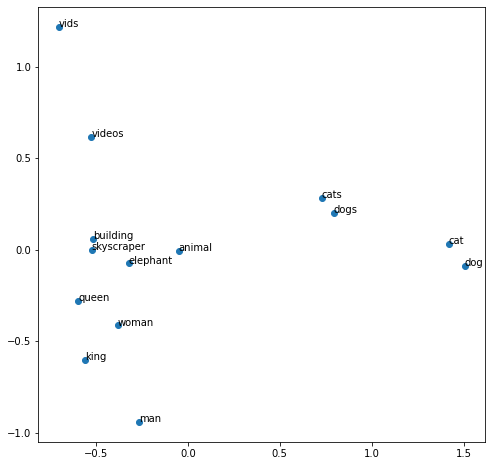

In [25]:
#hide_input
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
p_comp = pca.fit_transform(vecs)
x = [p[0] for p in p_comp]
y = [p[1] for p in p_comp]

plt.figure(figsize=(8,8))
plt.scatter(x, y)

for i, x, y in zip(range(len(words)), x, y):
    plt.text(x, y, words[i])
    
plt.show()

Here, we've done principal component analysis (PCA) to turn our word vectors from 300 dimensions to 2. This means that if our previous vectors consisted of 300 numbers each, now they consist of just 2. We obviously lose a lot of information in the process, but we can at least visualise them in a 2D plot.

You can see that related words are close to each other, while unrelated words are farther away. Due to PCA, the distances aren't very accurately represented, but hopefully you can see that there is a level of understanding behind the vectors.

To further demonstrate this, I'll show a popular example of doing arithmetic with words.

What is ```king - man + woman```?

In [26]:
#hide
from scipy import spatial

In [27]:
# Easily compare similarity between vectors
def cosine_similarity(vec1, vec2):
    return round(1 - spatial.distance.cosine(vec1, vec2), 4)

In [28]:
calc_queen = word_vecs["king"] - word_vecs["man"] + word_vecs["woman"]
cosine_similarity(calc_queen, word_vecs["queen"])

0.6543

Using [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) to compare vectors, we get a result of roughly `0.65`. As cosine similarity ranges from -1 to 1, this means the vectors are very similar.

It turns out that ```king - man + woman``` is roughly equal to queen. Very cool!

To verify this and see if this approach could help us with cats, dogs, animals and everything else we've been trying we can do more comparisons.

In [29]:
cosine_similarity(word_vecs["cat"], word_vecs["cats"])

0.835

In [30]:
cosine_similarity(word_vecs["cats"], word_vecs["dogs"])

0.7548

As we hoped, `cat` is similar to `cats`, which is also similar to `dogs`, but less so. Looking good!

In [31]:
cosine_similarity(word_vecs["cat"], word_vecs["animal"])

0.5026

In [32]:
cosine_similarity(word_vecs["skyscraper"], word_vecs["animal"])

0.0665

And as expected, `cat` is similar to `animal`, while `skyscraper` isn't.

In [33]:
cosine_similarity(word_vecs["vids"], word_vecs["videos"])

0.7223

As a final test, we can see that it also handles slang. Looks promising. Let's write an indexing function for keyword vectors. 

In [34]:
def level3_index_documents(documents):
    index = []
    for document in documents:
        # Get list of keywords
        kws = text_to_keywords(document)
        # Count number of keywords
        length = len(kws)
        # Count all keywords
        counts = dict(collections.Counter(kws))
        kw_vector_counts = {kw: {"count": count, "vector": ft.get_word_vector(kw)}
                            for kw, count in counts.items()}
        
        # Nice index representation
        indexed_document = {"doc": document, "vector_counts": kw_vector_counts,
                           "length": length}
        # Add to our index
        index.append(indexed_document)
    
    return index

All that we have done for indexing is saving the keyword vectors alongside their counts.

In [35]:
level3_index = level3_index_documents([doc_1, doc_2, doc_3, doc_4])

In [36]:
def level3_rank(query, index):
    results = []
    # Split query to keywords
    kws = text_to_keywords(query)
    # Get vectors for each keyword in query
    query_kw_vectors = [ft.get_word_vector(kw) for kw in kws]
    # Iterate over all documents
    for document in index:
        score = 0.0
        # Iterate over all query keyword vectors
        for query_kw_vector in query_kw_vectors:
            # Iterate over all document keyword vectors
            for _, vector_counts in document["vector_counts"].items():
                doc_kw_vector = vector_counts["vector"]
                doc_kw_count = vector_counts["count"]
                
                # Weigh repeated document keywords
                # as exponentially less important
                score += math.log(doc_kw_count + 2) \
                       * cosine_similarity(query_kw_vector, doc_kw_vector)
        
        # Normalize score over keyword * document lenghts
        score = score / len(query_kw_vectors) / document["length"]
        
        result = {"doc": document, "score": score}
        results.append(result)
    
    # Sort results
    results = sorted(results, key=lambda x: x["score"], reverse=True)
    return results

For the ranking, we weigh repeated keywords as exponentially less important. We use cosine similarity between each of the query and document keywords and sum up the score that's normalised over query and document length.

In [37]:
search("animal clips", level3_rank, level3_index)

silly dog videos               0.3430
Funny videos about cats        0.2856
viral triple rainbow clip      0.2360
Cats, cats, cats!              0.1553


Perfect, searching for "animal clips" gives us cat and dog videos as the top result, even though they have no words or tokens in common.

In [38]:
search("hats hats hats", level3_rank, level3_index)

silly dog videos               0.1921
Funny videos about cats        0.1849
Cats, cats, cats!              0.1387
viral triple rainbow clip      0.1334


Since we are not relying on n-grams anymore, we don't make a blunder here. Notice that the top scores are considerably lower than for the last search.

In [39]:
search("how to build a skyscraper", level3_rank, level3_index)

Funny videos about cats        0.1323
viral triple rainbow clip      0.1170
silly dog videos               0.1015
Cats, cats, cats!              0.0300


A completely unrelated query gives us low scores. Let's index another document to try something a bit more challenging.

In [40]:
doc_5 = "footage about toy animals"
level3_index = level3_index_documents([doc_1, doc_2, doc_3, doc_4, doc_5])

In [41]:
search("videos of animals", level3_rank, level3_index)

footage about toy animals      0.2993
Funny videos about cats        0.2956
silly dog videos               0.2845
Cats, cats, cats!              0.1547
viral triple rainbow clip      0.1464


Here's our first problem. As our similarity matching is purely on a word-level, we get an irrelevant result as the top result. `videos` matches well with `footage` and `animals` matches perfectly with `animals`.

Due to word-level limitations, we can't tell that `toy animals` and `animals` are very different.

In [42]:
search("cat videos", level3_rank, level3_index)

silly dog videos               0.4435
Funny videos about cats        0.4062
footage about toy animals      0.2861
Cats, cats, cats!              0.2778
viral triple rainbow clip      0.2238


Can you figure out what's happening here?

In [43]:
cosine_similarity(ft.get_word_vector("cat"), ft.get_word_vector("dog"))

0.7079

In [44]:
cosine_similarity(ft.get_word_vector("cat"), ft.get_word_vector("cats"))

0.835

It seems that `cat` is more similar to `cats` than to `dog`. That's good. The only reason for the worse score can be due to the other words in the documents.

In specific, `funny` and `about` are dragging the average score down more than `silly`.

What now? We've managed to introduce understanding into our search engine. We can now get away without any n-gram tokenisation and get synonym support out of the box. Additionally, we have a better way of detecting whether there are any relevant results. We could say that anything below the score of `0.15-0.20` is not relevant. Whereas with the previous level, the scoring was much more arbitrary.

There's another problem which hasn't been mentioned, and that's scale. The current implementation needs to save word vectors for every keyword. For ranking, we need to compare every single query keyword with each document keyword for every available document. Sure, there are some efficiency tricks we can do here and there, but our engine still relies entirely on vector comparisons. That's bad for scale, both in terms of space and time.

Our level 2 token matching engine was much more efficient (and it can still be improved). We could quickly access the relevant tokens and have a lot of pre-processed information about every document. Here, for level 3, we depend on comparing a lot of different vectors, since we can't rely on exact matches.

While we improved on relevancy through understanding, we took a big hit on scalability. This is a no go. Search becomes more critical the more documents you have. Speaking of more documents, I'm reasonably confident that the BM25 ranking algorithm would perform better in most real-world scenarios. Large amounts of text introduce a lot of "noise", which BM25 is built to handle.

It's possible to merge the two approaches, but it's time to climb a level higher.

### Level 4 - Sentence to document level semantics

With Level 4, we are trying to solve the limitations of word only semantics and build a more scalable system. It's time to ditch word vectors and use techniques that can capture accurate vectors about sentences, paragraphs and entire documents. Not all AI is created equal.

Say we could produce a single vector for our query and every document. Then, we could compare our query with every available document just once, giving us linear time and space complexities. Great! And if that's not good enough, there are appropriate vector search libraries out there, such as [ANNOY](https://github.com/spotify/annoy). If a single vector is enough to capture the meaning/information of queries and documents, then we're well off!

Perhaps surprisingly, the implementation for Level 4 is as easy as Level 1, that is, if you don't need to implement the language model from scratch. Luckily, for the past few years, there has been a considerable amount of research in this area (and it is still ongoing).

One of the most important models in this area is [BERT](https://github.com/google-research/bert), which was created and released in 2018 by Google. And since October 2020, it is used for all English queries in Google search. What makes it different from our word vector approach is that it takes context into account.

Consider two sentences:

1. She is standing on the river bank.
2. She is opening a bank account.

Clearly the word `bank` has two different meanings in the sentences. If you only have a single vector per word, you can't possibly represent two different meanings accurately.

Additionally, BERT can consider meaning in both directions, which is why it is called a bidirectional model. In plain English, this means that BERT looks at the entire sentence before making the final prediction. Remember my proposed approach for learning word vectors? It involved trying to predict the next word given a sequence of words.

BERT is trained differently; it is asked to predict words within sentences, such as:

"The man went to the \_\_\_. He bought a \_\_\_ of milk."

It does some other tricks, but that's basically it. Thanks to the training and its architecture, it can represent entire sentences and documents as vectors.

Additionally, it is relatively quick and inexpensive to finetune, which means adapting it to your specific domain. This has created an explosion of models and libraries built around BERT. While I won't be showing how to train a similar model from scratch, nor how to finetune BERT (though both would be fun and blog-worthy), we'll cover how easy existing models are to use.

It's time to build our Level 4 search engine.

In [45]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("distilroberta-base-paraphrase-v1")

def level4_index_documents(documents):
    index = []
    for document in documents:
        # Calculate vector for document
        vector = model.encode(document)
        # Nice index representation
        indexed_document = {"doc": document, "vector": vector}
        # Add to our index
        index.append(indexed_document)
    
    return index

In [46]:
level4_index = level4_index_documents([doc_1, doc_2, doc_3, doc_4, doc_5])

The only new thing here is our language model. We use an incredible library called [Sentence Transformers](https://github.com/UKPLab/sentence-transformers), which is excellent at producing sentence vectors from transformer-based language models, such as BERT. The specific model we use does not matter too much, but every model excels in its own domain.

It depends on the type of data the model was trained/fine-tuned on. The model used is a modified and fine-tuned variant of BERT that happens to be suitable for our queries and documents.

For an optimal solution, you'd need to finetune a model on your own data.

In [47]:
def level4_rank(query, index):
    results = []
    # Calculate vector for query
    query_vector = model.encode(query)
    for document in index:
        # Compare the query and document vectors
        score = cosine_similarity(query_vector, document["vector"])
        
        result = {"doc": document, "score": score}
        results.append(result)
    
    # Sort results
    results = sorted(results, key=lambda x: x["score"], reverse=True)
    return results

All we do here is calculate a vector for our query and compare its similarity with every document vector.

In [48]:
search("animal clips", level4_rank, level4_index)

silly dog videos               0.5840
Funny videos about cats        0.4831
footage about toy animals      0.3808
Cats, cats, cats!              0.3181
viral triple rainbow clip      0.3005


In [49]:
search("cat videos", level4_rank, level4_index)

Funny videos about cats        0.7001
silly dog videos               0.5884
Cats, cats, cats!              0.4314
footage about toy animals      0.3773
viral triple rainbow clip      0.2705


In [50]:
search("videos of animals", level4_rank, level4_index)

silly dog videos               0.6273
Funny videos about cats        0.6228
footage about toy animals      0.4136
Cats, cats, cats!              0.4081
viral triple rainbow clip      0.2008


Toy animals are no longer on top and cat videos are about cats, not dogs. Awesome!

Looking closer at the scores, it seems that anything above `0.4-0.45` is relevant. This makes it easy to detect when we don't have anything good to show.

In [51]:
search("raising a cat", level4_rank, level4_index)

Funny videos about cats        0.3356
Cats, cats, cats!              0.3231
silly dog videos               0.2472
footage about toy animals      0.1689
viral triple rainbow clip      0.1097


Even if the results contain the right keyword, it does not always mean that they are relevant. That's what we hoped to achieve. 

#### Open source implementation

To reach this point, we've done plenty of significant work. As you can expect, if we wanted to productionise this, we'd need to do even more. Ensuring that large language models scale smoothly is no easy feat.

This is something, we've worked hard on at Kiri. We recently released our open source [Natural Language Engine](https://github.com/kiri-ai/kiri) that among other things makes building an intelligent search engine incredibly easy. What's more, it works in over 50 languages. Let's have a look.

In [52]:
from kiri import Kiri, Document

# Take your search to production with our API
kiri = Kiri(api_key="abc")
# Or run locally
kiri = Kiri(local=True)

documents = [Document(d) for d in [doc_1, doc_2, doc_3, doc_4, doc_5]]
# Equivalent to our "index" functions
kiri.upload(documents)

In [53]:
# Display search results nicely
def kiri_search(query):
    results = kiri.search(query)
    for result in results.results:
        print(f"{result.document.content} \t {result.score:.4f}".expandtabs(30))

In [54]:
kiri_search("videos of animals")

Funny videos about cats        0.4718
silly dog videos               0.4095
footage about toy animals      0.3761
Cats, cats, cats!              0.2332
viral triple rainbow clip      0.1327


Combining this approach with BM25 (for example with Elasticsearch) is how you can achieve state of the art search results. If this is something you're interested in, check out an example [here](https://github.com/kiri-ai/kiri/blob/main/examples/core_functionality/Search.ipynb).

#### Level 4 limitations

In [55]:
search("everything except animal videos", level4_rank, level4_index)

Funny videos about cats        0.5970
silly dog videos               0.5647
Cats, cats, cats!              0.4448
footage about toy animals      0.3932
viral triple rainbow clip      0.3138


You may think, "hold on now, that's not how you search!". To which I would say, why not? Just because we are used to searching in one way, who's to say a different way isn't better? I know what I want to find, but I am being forced to do it in a way the search engine likes, not the way I like.

The way we search is just a limitation of our technology, and the next level is all about advancing it.

### Level 5 - Broader to General Intelligence

If you have noticed the trend, then with each level we have become more and more general. We started with individual keywords that couldn't match singular, plural forms and compound words. We moved on to token matching that could do the aforementioned. Token matching was limited in understanding similar words and made some errors due to, well, the nature of token matching.

We introduced first traces of intelligence with word vectors that captured some meaning. Where we fell short was the relationships _between_ words. Logically enough, we upgraded and captured the meanings of word relationships. Our shortage here was a lack of knowledge about other documents and a "one approach that fits all" solution. While we improved the results, we definitely didn't solve search.

Where to from here? What we need is more intelligence, and specifically, broader intelligence.

Think about why you or anyone else searches. It is to find information. Doesn't it make sense to find exactly what you're looking for, instead of finding traces that you need to put together manually? Say you're trying to find how many different animal species there are or how many customer complaints your company has received in the last quarter. You'll be successful only if that data is already analysed. That is, someone has written a paper on the topic or put together a formal report. In many cases, the information is already there! You just need the right intelligence to analyse it.

From here on, your imagination is the limit. The world is full of unstructured data like text. What gems may we find and what problems could we solve, given an intelligence that analyses the world's information and connects the right bits?

For the time being, there isn't a solution. However, making state-of-the-art AI more accessible is our mission at [Kiri](https://kiri.ai/). Once level 5 search is possible, we'll be sure to make it easy to use.